# TCC Experimento 1: Detecção de Veículos (UA-DETRAC)

**Objetivo**: Avaliar a resiliência e performance de YOLOv8, SSD e Faster R-CNN em diferentes cenários simulados.

---
**Métricas**: Precision, Recall, F1, mAP, FPS.

## 1. Configuração e Ambiente

In [ ]:
import sys, cv2, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import torch

# Configuração de caminhos dinâmicos
BASE_DIR = Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

DS_PROC        = BASE_DIR / "dataset_processado"
UA_ROOT        = BASE_DIR / "UA-DETRAC"
RESULTS_DIR    = DS_PROC / "resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_SAMPLES = 300   # Ajuste conforme necessário

device = "GPU" if torch.cuda.is_available() else "CPU"
print(f"Dispositivo : {device}")
print(f"UA-DETRAC   : {'Encontrado' if UA_ROOT.exists() else 'NÃO ENCONTRADO'}")

Dispositivo : CPU
UA-DETRAC   : Encontrado


## 2. Análise do Dataset UA-DETRAC

Total de imagens: 140,131
  - Diurno: 97,703
  - Noturno: 1,529
  - Baixa Qualidade: 40,899


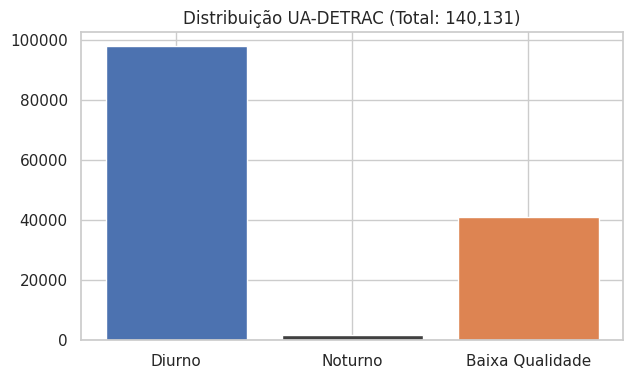

In [2]:
SCENARIOS = {
    "Diurno"         : DS_PROC / "diurno",
    "Noturno"        : DS_PROC / "noturno",
    "Baixa Qualidade": DS_PROC / "baixa_qualidade",
}

counts = {}
for name, path in SCENARIOS.items():
    imgs = list(path.glob("*.jpg")) + list(path.glob("*.png"))
    counts[name] = len(imgs)

total = sum(counts.values())
print(f"Total de imagens: {total:,}")

for name, count in counts.items():
    print(f"  - {name}: {count:,}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.keys(), counts.values(), color=["#4C72B0", "#404040", "#DD8452"])
ax.set_title(f"Distribuição UA-DETRAC (Total: {total:,})")
plt.show()

## 3. Experimentos de Detecção

In [3]:
from src.models.detectors import YOLODetector, TorchvisionDetector

models = {
    "YOLOv8": YOLODetector("yolov8n.pt"),
    "SSD": TorchvisionDetector("ssd"),
    "Faster R-CNN": TorchvisionDetector("faster_rcnn")
}

from src.utils.ua_detrac_runner import run_ua_detrac_benchmark

df_ua = run_ua_detrac_benchmark(
    scenario_dirs  = SCENARIOS,
    models_config  = list(models.items()),
    ua_detrac_root = UA_ROOT,
    n_samples      = N_SAMPLES,
)
df_ua.to_csv(RESULTS_DIR / "ua_detrac_benchmark.csv", index=False)
display(df_ua.head())

Indexando labels do UA-DETRAC...
  117233 labels indexados.


KeyboardInterrupt: 

## 4. Resumo de Resultados

In [ ]:
summary_ua = df_ua.groupby(["model", "scenario"]).agg(
    Precision = ("precision", "mean"),
    Recall    = ("recall",    "mean"),
    F1        = ("f1",        "mean"),
    FPS       = ("fps",       "mean")
).round(3)

display(summary_ua)

from src.utils.ua_detrac_runner import compute_map_from_df
map_df = compute_map_from_df(df_ua)
display(map_df[map_df["scenario"] == "GERAL (mAP)"])

Precision  Recall     F1     FPS
model        scenario                                         
Faster R-CNN Baixa Qualidade      0.570   0.701  0.601   0.546
             Diurno               0.475   0.676  0.519   0.554
             Noturno              0.642   0.675  0.630   0.546
SSD          Baixa Qualidade      0.452   0.127  0.190  17.720
             Diurno               0.306   0.054  0.087  18.093
             Noturno              0.617   0.200  0.281  17.895
YOLOv8       Baixa Qualidade      0.629   0.682  0.615  16.297
             Diurno               0.418   0.605  0.455  16.618
             Noturno              0.700   0.741  0.707  15.958

,model,scenario,AP
9,Faster R-CNN,GERAL (mAP),0.446500
10,SSD,GERAL (mAP),0.120667
11,YOLOv8,GERAL (mAP),0.465067


# 5. Visualizaçao Grafica

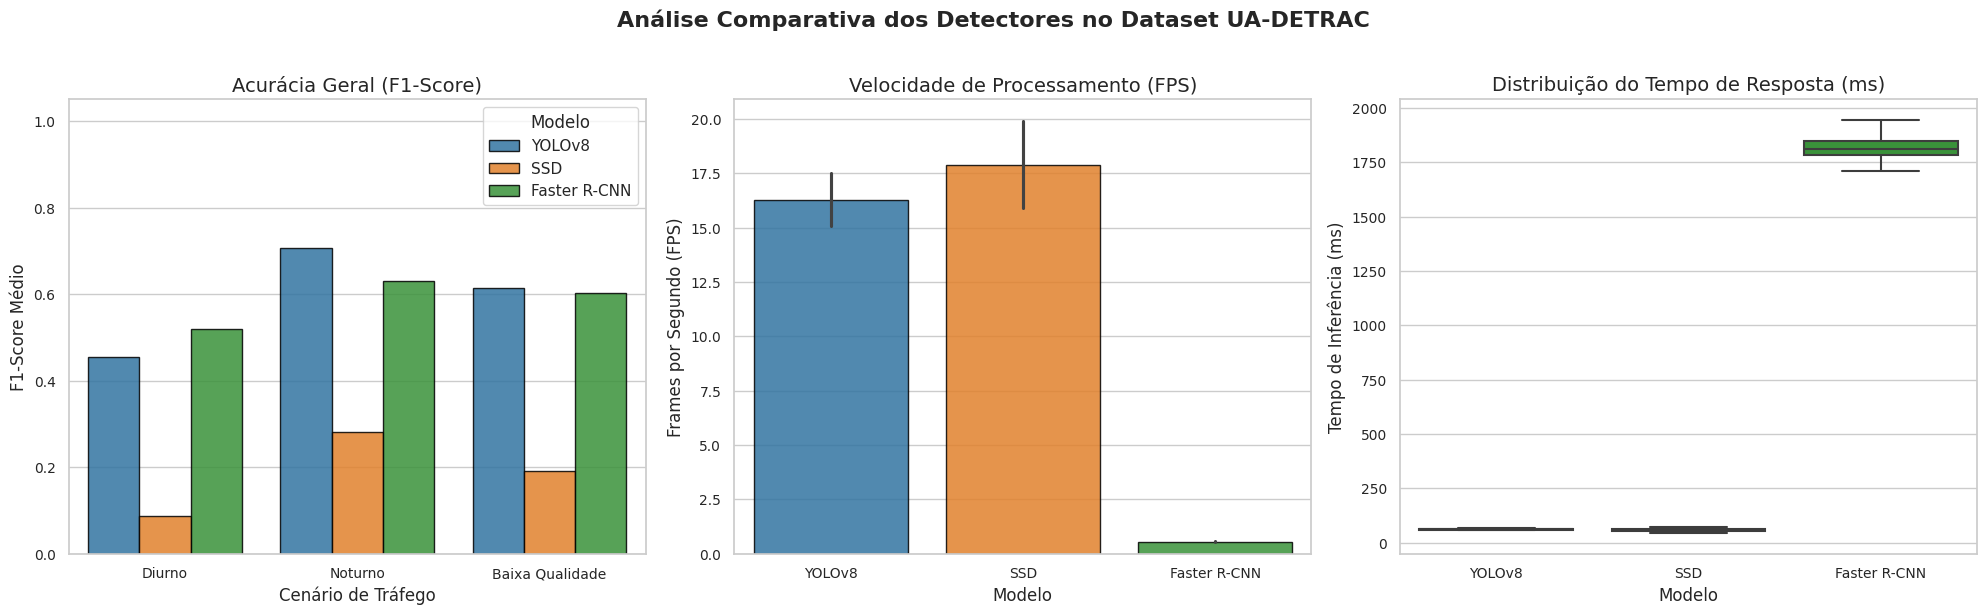

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})
# Criação da figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Análise Comparativa dos Detectores no Dataset UA-DETRAC", weight='bold', y=1.02)
# Cores modernas e distintas para os modelos
model_palette = {"YOLOv8": "#1f77b4", "SSD": "#ff7f0e", "Faster R-CNN": "#2ca02c"}
# --- GRÁFICO 1: F1-Score por Cenário ---
sns.barplot(
    data=df_ua, 
    x="scenario", 
    y="f1", 
    hue="model", 
    palette=model_palette, 
    ax=axes[0], 
    errorbar=None,
    edgecolor="black", 
    alpha=0.85
)
axes[0].set_title("Acurácia Geral (F1-Score)")
axes[0].set_xlabel("Cenário de Tráfego")
axes[0].set_ylabel("F1-Score Médio")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Modelo")
# --- GRÁFICO 2: FPS (Velocidade) por Modelo ---
# O FPS não varia tanto por cenário, então agrupamos por modelo
sns.barplot(
    data=df_ua, 
    x="model", 
    y="fps", 
    palette=model_palette, 
    ax=axes[1], 
    errorbar="sd", # Mostra o desvio padrão da velocidade
    edgecolor="black", 
    alpha=0.85,
    hue="model",
    legend=False
)
axes[1].set_title("Velocidade de Processamento (FPS)")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("Frames por Segundo (FPS)")
# --- GRÁFICO 3: Distribuição do Tempo de Inferência (Latência em ms) ---
sns.boxplot(
    data=df_ua, 
    x="model", 
    y="time_ms", 
    palette=model_palette, 
    ax=axes[2], 
    showfliers=False, # Oculta outliers para melhorar a visualização
    linewidth=1.5,
    hue="model",
    legend=False
)
axes[2].set_title("Distribuição do Tempo de Resposta (ms)")
axes[2].set_xlabel("Modelo")
axes[2].set_ylabel("Tempo de Inferência (ms)")
plt.tight_layout()
plt.show()

# Densidade vs acuracia

In [15]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random

from src.utils.metrics import match_detections
from src.utils.ua_detrac_runner import _build_label_index, _yolo_to_abs

UA_CLASSES = {
    0: 'car',
    1: 'van',
    2: 'bus',
    3: 'truck'
}

COCO_CLASS_MAP = {
    '2': 'car',
    '3': 'car',   # deixei por segurança caso seu detector use índice deslocado
    '5': 'bus',
    '6': 'bus',
    '7': 'truck',
    '8': 'truck',

    'car': 'car',
    'automobile': 'car',
    'vehicle': 'car',

    'bus': 'bus',

    'truck': 'truck',
    'lorry': 'truck',

    'van': 'van',
    'suv': 'van',
    'minivan': 'van'
}

def carregar_gt_com_classe(label_path, img_w, img_h, merge_van_into_car=True):
    if not label_path or not Path(label_path).exists():
        return []

    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cls = int(parts[0])
            cls_name = UA_CLASSES.get(cls, 'car')

            if merge_van_into_car and cls_name == 'van':
                cls_name = 'car'

            cx, cy, bw, bh = map(float, parts[1:5])
            box = _yolo_to_abs(cx, cy, bw, bh, img_w, img_h)
            boxes.append((cls_name, box))

    return boxes

def normalizar_pred_classe(raw_cls, merge_van_into_car=True):
    if raw_cls is None:
        return None

    cls = str(raw_cls).strip().lower()
    mapped = COCO_CLASS_MAP.get(cls, None)

    if mapped is None:
        return None

    if merge_van_into_car and mapped == 'van':
        mapped = 'car'

    return mapped

def extrair_classe_predicao(d):
    for key in ['class', 'label', 'class_name', 'category', 'name']:
        if key in d and d[key] is not None:
            return d[key]
    return None

def analisar_seletividade(
    models_dict,
    scenario_dirs,
    ua_root,
    sample_size=N_SAMPLES,
    iou_threshold=0.5,
    merge_van_into_car=True,
    debug=True
):
    print("=== INICIANDO ANÁLISE DE SELETIVIDADE ===")
    random.seed(42)

    label_index = _build_label_index(ua_root)
    print(f"Quantidade de labels indexadas: {len(label_index)}")

    eval_classes = ['car', 'bus', 'truck'] if merge_van_into_car else ['car', 'van', 'bus', 'truck']

    annotated_images = []

    print("\n=== VERIFICANDO CENÁRIOS ===")
    for scenario_name, scenario_dir in scenario_dirs.items():
        scenario_dir = Path(scenario_dir)

        img_paths = list(scenario_dir.rglob('*.jpg')) + list(scenario_dir.rglob('*.png'))
        valid_paths = [p for p in img_paths if p.stem in label_index]

        print(f"\nCenário: {scenario_name}")
        print(f" - Diretório: {scenario_dir}")
        print(f" - Total de imagens encontradas: {len(img_paths)}")
        print(f" - Imagens com label correspondente: {len(valid_paths)}")

        if valid_paths:
            sampled = random.sample(valid_paths, min(sample_size, len(valid_paths)))
            annotated_images.extend(sampled)

    print(f"\nTotal de imagens selecionadas para análise: {len(annotated_images)}")

    if not annotated_images:
        print("ERRO: nenhuma imagem anotada foi encontrada.")
        print("Verifique se os nomes das imagens batem com os labels do UA-DETRAC.")
        return None

    records = []

    for model_name, detector in models_dict.items():
        print(f"\n==============================")
        print(f"Processando modelo: {model_name}")
        print(f"==============================")

        total_preds_model = 0

        if debug:
            try:
                img_debug = cv2.imread(str(annotated_images[0]))
                preds_debug = detector.detect(img_debug)

                print(f"\nExemplo de predições brutas de {model_name}:")
                if not preds_debug:
                    print(" - Nenhuma predição retornada")
                else:
                    for p in preds_debug[:10]:
                        print(p)
            except Exception as e:
                print(f"Erro ao gerar debug de predição: {e}")

        for idx, img_path in enumerate(annotated_images):
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"[WARN] Não foi possível abrir a imagem: {img_path}")
                continue

            h, w = img.shape[:2]

            gt_file = label_index.get(img_path.stem)
            gt_items = carregar_gt_com_classe(
                gt_file, w, h, merge_van_into_car=merge_van_into_car
            )

            try:
                detections = detector.detect(img)
            except Exception as e:
                print(f"[ERRO] detector.detect falhou em {img_path.name}: {e}")
                continue

            total_preds_model += len(detections)

            gt_by_class = {cls: [] for cls in eval_classes}
            for cls_name, box in gt_items:
                if cls_name in gt_by_class:
                    gt_by_class[cls_name].append(box)

            pred_by_class = {cls: [] for cls in eval_classes}
            pred_classes_encontradas = []

            for d in detections:
                raw_cls = extrair_classe_predicao(d)
                pred_cls = normalizar_pred_classe(raw_cls, merge_van_into_car=merge_van_into_car)

                if raw_cls is not None:
                    pred_classes_encontradas.append(str(raw_cls))

                if pred_cls in pred_by_class and 'bbox' in d:
                    pred_by_class[pred_cls].append(d['bbox'])

            if debug and idx < 3:
                print(f"\n[DEBUG] Imagem: {img_path.name}")
                print(f"GT por classe: {{c: len(v) for c, v in gt_by_class.items()}}")
                print(f"Classes preditas brutas: {pred_classes_encontradas[:10]}")
                print(f"Predições válidas por classe: { {c: len(v) for c, v in pred_by_class.items()} }")

            for cls_name in eval_classes:
                gt_boxes = gt_by_class[cls_name]
                pred_boxes = pred_by_class[cls_name]

                tp, fp, fn = match_detections(
                    pred_boxes,
                    gt_boxes,
                    iou_threshold=iou_threshold
                )

                records.append({
                    'model': model_name,
                    'class': cls_name,
                    'tp': tp,
                    'fp': fp,
                    'fn': fn,
                    'n_gt': len(gt_boxes),
                    'n_pred': len(pred_boxes)
                })

        print(f"Total de predições retornadas por {model_name}: {total_preds_model}")

    df_class = pd.DataFrame(records)

    if df_class.empty:
        print("Nenhum resultado foi gerado.")
        return None

    df_agg = (
        df_class
        .groupby(['model', 'class'], as_index=False)
        .sum()
    )

    df_agg['precision'] = df_agg['tp'] / (df_agg['tp'] + df_agg['fp'] + 1e-9)
    df_agg['recall'] = df_agg['tp'] / (df_agg['tp'] + df_agg['fn'] + 1e-9)
    df_agg['f1'] = 2 * df_agg['precision'] * df_agg['recall'] / (
        df_agg['precision'] + df_agg['recall'] + 1e-9
    )

    df_agg = df_agg.sort_values(['class', 'model']).reset_index(drop=True)

    print("\n===== RESULTADO FINAL =====")
    print(df_agg[['model', 'class', 'n_gt', 'n_pred', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1']].to_string(index=False))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_agg,
        x="class",
        y="f1",
        hue="model",
        edgecolor="black",
        alpha=0.85
    )

    titulo = "Acurácia (F1-Score) por Categoria de Veículo"
    if merge_van_into_car:
        titulo += " (van agrupada em car)"

    plt.title(titulo, weight='bold', fontsize=14)
    plt.xlabel("Categoria de Veículo", fontsize=12)
    plt.ylabel("F1-Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(title="Modelo")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_agg

=== INICIANDO ANÁLISE DE SELETIVIDADE ===
Quantidade de labels indexadas: 117233

=== VERIFICANDO CENÁRIOS ===

Cenário: Diurno
 - Diretório: /home/nicman/Desktop/TCC1/dataset_processado/diurno
 - Total de imagens encontradas: 97703
 - Imagens com label correspondente: 78499

Cenário: Noturno
 - Diretório: /home/nicman/Desktop/TCC1/dataset_processado/noturno
 - Total de imagens encontradas: 1529
 - Imagens com label correspondente: 1487

Cenário: Baixa Qualidade
 - Diretório: /home/nicman/Desktop/TCC1/dataset_processado/baixa_qualidade
 - Total de imagens encontradas: 40899
 - Imagens com label correspondente: 37247

Total de imagens selecionadas para análise: 150

Processando modelo: YOLOv8

Exemplo de predições brutas de YOLOv8:
{'bbox': [302.94989013671875, 367.614501953125, 478.86932373046875, 497.6533203125], 'conf': 0.8940957188606262, 'class': 'car'}
{'bbox': [521.3974609375, 132.6485595703125, 595.34619140625, 180.86322021484375], 'conf': 0.8283538222312927, 'class': 'car'}
{'b

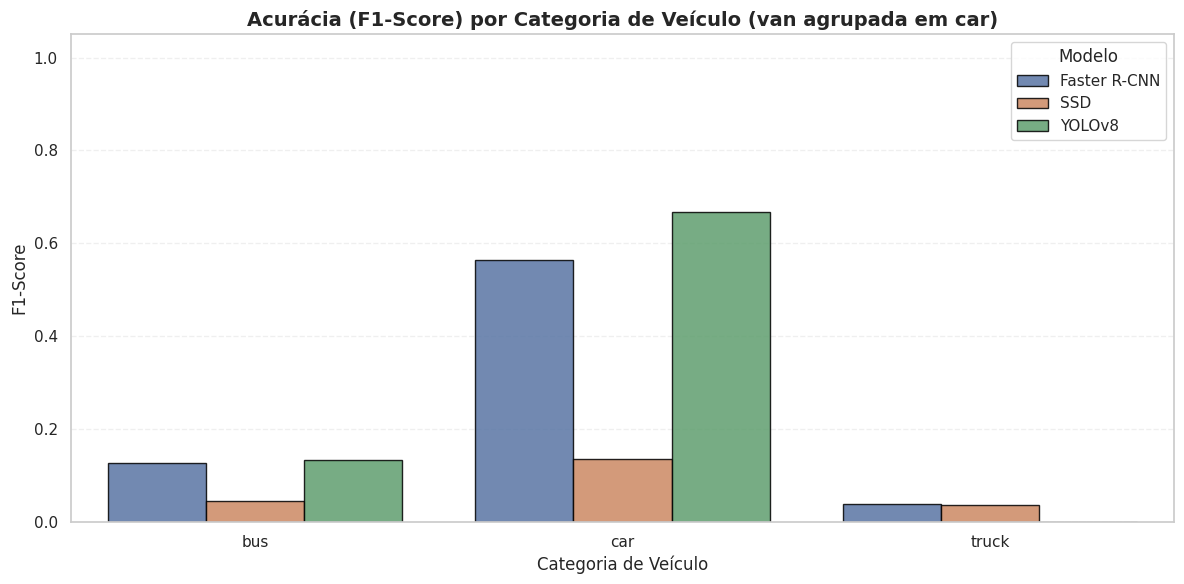

,model,class,tp,fp,fn,n_gt,n_pred,precision,recall,f1
0,Faster R-CNN,bus,14,127,65,79,141,0.099291,0.177215,0.127273
1,SSD,bus,3,53,76,79,56,0.053571,0.037975,0.044444
2,YOLOv8,bus,18,174,61,79,192,0.093750,0.227848,0.132841
3,Faster R-CNN,car,655,718,297,952,1373,0.477058,0.688025,0.563441
4,SSD,car,69,5,883,952,74,0.932432,0.072479,0.134503
5,YOLOv8,car,700,444,252,952,1144,0.611888,0.735294,0.667939
6,Faster R-CNN,truck,4,116,89,93,120,0.033333,0.043011,0.037559
7,SSD,truck,2,18,91,93,20,0.100000,0.021505,0.035398
8,YOLOv8,truck,0,63,93,93,63,0.000000,0.000000,0.000000


In [16]:
df_sel = analisar_seletividade(
    models_dict=models,
    scenario_dirs=SCENARIOS,
    ua_root=UA_ROOT,
    sample_size=N_SAMPLES,
    iou_threshold=0.5,
    merge_van_into_car=True,
    debug=True
)

df_sel